In [128]:
import numpy as np
import pandas as pd

In [129]:
df = pd.read_csv('/content/liver_cirrhosis.csv')

In [130]:
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [131]:
df.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,1887.117040,18495.877080,3.402644,372.331471,3.486578,100.184663,1995.675597,123.166345,123.822548,256.007337,10.734549,2.00116
std,1091.690918,3737.596616,4.707491,193.668452,0.380488,73.184840,1798.885660,47.747616,52.786350,98.679006,0.904436,0.81387
min,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.00000
25%,1080.000000,15694.000000,0.800000,275.000000,3.290000,52.000000,1032.000000,92.000000,92.000000,189.000000,10.000000,1.00000
50%,1680.000000,18499.000000,1.300000,369.510563,3.510000,97.648387,1828.000000,122.556346,124.702128,251.000000,10.600000,2.00000
75%,2576.000000,20955.000000,3.400000,369.510563,3.750000,107.000000,1982.655769,134.850000,127.000000,311.000000,11.100000,3.00000
max,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,3.00000


In [132]:
df.isnull().sum()

,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


In [133]:
df['Stage'].nunique()

3

In [134]:
df['Stage'].value_counts()

,count
Stage,
2,8441
3,8294
1,8265


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         25000 non-null  int64  
 1   Status         25000 non-null  object 
 2   Drug           25000 non-null  object 
 3   Age            25000 non-null  int64  
 4   Sex            25000 non-null  object 
 5   Ascites        25000 non-null  object 
 6   Hepatomegaly   25000 non-null  object 
 7   Spiders        25000 non-null  object 
 8   Edema          25000 non-null  object 
 9   Bilirubin      25000 non-null  float64
 10  Cholesterol    25000 non-null  float64
 11  Albumin        25000 non-null  float64
 12  Copper         25000 non-null  float64
 13  Alk_Phos       25000 non-null  float64
 14  SGOT           25000 non-null  float64
 15  Tryglicerides  25000 non-null  float64
 16  Platelets      25000 non-null  float64
 17  Prothrombin    25000 non-null  float64
 18  Stage 

In [136]:
df.columns

Index(['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly',
       'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='object')

In [137]:
cols = []
for col in df.columns:
  if df[col].dtype == 'object':
    print(df[col].value_counts())
    cols.append(col)
    print()

Status
C     13516
D      9456
CL     2028
Name: count, dtype: int64

Drug
Placebo            15827
D-penicillamine     9173
Name: count, dtype: int64

Sex
F    22137
M     2863
Name: count, dtype: int64

Ascites
N    16798
Y     8202
Name: count, dtype: int64

Hepatomegaly
N    15243
Y     9757
Name: count, dtype: int64

Spiders
N    13614
Y    11386
Name: count, dtype: int64

Edema
N    20220
S     3698
Y     1082
Name: count, dtype: int64



In [138]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cols:
  df[col] = le.fit_transform(df[col])

In [139]:
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,0,1,18499,0,0,1,0,0,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,0,1,19724,1,1,0,1,0,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,0,1,11839,0,0,0,0,0,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,2,1,16467,0,0,0,0,0,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,2,1,21699,0,0,1,0,0,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [140]:
#convert the age in years
df['Age'] = df['Age'].apply(lambda x: x//365)

In [141]:
df.corr()['Stage']

,Stage
N_Days,-0.309484
Status,0.275194
Drug,0.030862
Age,0.164968
Sex,0.061687
Ascites,0.111012
Hepatomegaly,0.353210
Spiders,0.168049
Edema,0.251095
Bilirubin,0.168006


<Axes: >

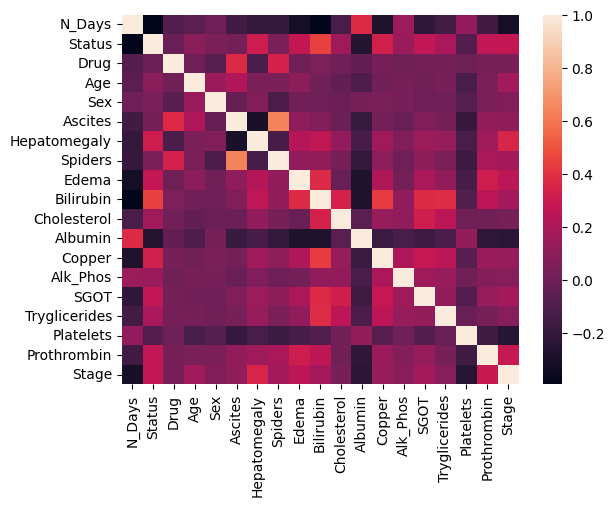

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=False)

In [143]:
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,0,1,50,0,0,1,0,0,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,0,1,54,1,1,0,1,0,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,0,1,32,0,0,0,0,0,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,2,1,45,0,0,0,0,0,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,2,1,59,0,0,1,0,0,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [144]:
X = df.drop('Stage', axis=1)
y = df['Stage'] - 1

In [145]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X = ss.fit_transform(X)

In [146]:
X

array([[ 3.05846309e-01, -8.86606760e-01,  7.61300992e-01, ...,
        -1.26593114e+00, -7.43532536e-05, -9.22747168e-01],
       [-6.01937941e-01, -8.86606760e-01,  7.61300992e-01, ...,
        -9.24927076e-01, -3.64900891e-01,  7.23681910e-02],
       [ 2.10401027e+00, -8.86606760e-01,  7.61300992e-01, ...,
        -8.30203725e-01, -3.14230538e-01, -8.12178794e-01],
       ...,
       [-8.39189324e-01,  1.23041034e+00, -1.31354091e+00, ...,
         1.66633455e-02, -1.54045307e+00,  2.50487240e+00],
       [ 1.66706467e+00, -8.86606760e-01, -1.31354091e+00, ...,
        -1.01965043e+00,  1.72271763e+00,  1.82936564e-01],
       [ 1.66706467e+00, -8.86606760e-01, -1.31354091e+00, ...,
        -1.01965043e+00,  1.72271763e+00,  1.82936564e-01]])

In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [149]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9554

In [150]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8528


In [151]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9212


In [152]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.6184


In [153]:
import xgboost as xgb

xgb = xgb.XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9614


In [154]:
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier([('rf', rf), ('gb', gb), ('dt', dt), ('ada', ada), ('xgb', xgb)])
vc.fit(X_train, y_train)
y_pred = vc.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9506


In [155]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [('rf', rf), ('gb', gb), ('dt', dt), ('ada', ada), ('xgb', xgb)]
sc = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(multi_class='multinomial', solver='lbfgs'))
sc.fit(X_train, y_train)
y_pred = sc.predict(X_test)
print(accuracy_score(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9646
